In [1]:
import xarray as xa
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.stats import pearsonr
from scipy.ndimage import maximum_filter, minimum_filter

import cartopy.crs as ccrs
from cartopy.feature import LAND, COASTLINE
import cmocean.cm as ocm

from scipy.optimize import minimize, rosen, rosen_der
from tqdm.notebook import tqdm
from multiprocessing import Pool

In [2]:
band_names = [
    'SI_12km_NH_18H_ASC',
    'SI_12km_NH_18V_ASC',
    'SI_12km_NH_23H_ASC',
    'SI_12km_NH_23V_ASC',
    'SI_12km_NH_36H_ASC',
    'SI_12km_NH_36V_ASC',
    'SI_12km_NH_89H_ASC',
    'SI_12km_NH_89V_ASC',
]
with xa.open_dataset('/data1/antonk/tmp/AMSR_U2_L3_SeaIce12km_B04_20230101.he5', group='HDFEOS/GRIDS/NpPolarGrid12km/Data Fields') as ds:
    bands = np.dstack([ds[band_name].to_numpy() for band_name in band_names])
    amsr2_sic = ds['SI_12km_NH_ICECON_ASC'].to_numpy()


In [3]:
with xa.open_dataset('/data1/antonk/tmp/AMSR_U2_L3_SeaIce12km_B04_20230101.he5', group='HDFEOS/GRIDS/NpPolarGrid12km') as ds:
    lon = ds.lon.to_numpy()
    lat = ds.lat.to_numpy()

In [4]:
titles = {
    #'siconc': 'Concentration',
    'sithick': 'Thickness',
    'siconc_my': 'MYI concentration',
    'siage': 'Ice Age',
    'si_ridge_ratio': 'Ridged ice (roughness)',
    'sisnthick': 'Snow thickness',
}
ifile = '/data1/antonk/nextsim_reanalysis/2023/01/20230101_dm-nersc-MODEL-nextsimf-ARC-RAN-fv00.0.nc'
with xa.open_dataset(ifile) as ds:
    data = {name: ds[name][0].to_numpy() for name in titles}
    x = ds.x.to_numpy()
    y = ds.y.to_numpy()
data['mask'] = np.isnan(data['sithick'])
data['mask'][0] = True
titles['mask'] = 'Landmask'


In [5]:
proj = ccrs.NorthPolarStereo(true_scale_latitude=90, central_longitude=-45)
amsr_x, amsr_y, _ = proj.transform_points(ccrs.PlateCarree(), lon, lat).T
amsr_x, amsr_y = amsr_x.T, amsr_y.T

In [6]:
amsr_data = {}
for name in titles:
    data[name] = np.where(np.isnan(data[name]), 0, data[name])
    s = RectBivariateSpline(y, x, data[name])
    amsr_data[name] = s(amsr_y, amsr_x, grid=False)
    print(name)

sithick
siconc_my
siage
si_ridge_ratio
sisnthick
mask


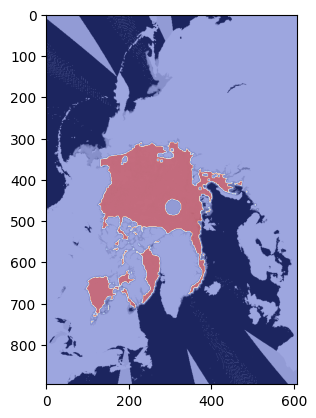

In [25]:
sic_filter = minimum_filter((amsr2_sic > 75) * (amsr2_sic <= 100), 5)
#sic_filter = (amsr2_sic > 85) * (amsr2_sic <= 100)
gpi = np.isfinite(bands[:,:,0]) * (amsr_data['mask'] < 0.5) * sic_filter
plt.imshow(amsr2_sic, cmap='gray')
plt.imshow(gpi, cmap='coolwarm', alpha=0.5)
plt.show()

In [26]:
feats = np.dstack([amsr_data[name] for name in titles if name != 'mask'])
bands_scale =  1 / bands[gpi, :].std(axis=0)
bands_offset =  - bands[gpi, :].mean(axis=0) / bands[gpi, :].std(axis=0)

feats_scale =  1 / feats[gpi, :].std(axis=0)
feats_offset =  - feats[gpi, :].mean(axis=0) / feats[gpi, :].std(axis=0)

bands_gpi = bands[gpi, :] * bands_scale + bands_offset
feats_gpi = feats[gpi, :] * feats_scale + feats_offset

bands_gpi.shape, feats_gpi.shape

((51764, 8), (51764, 5))

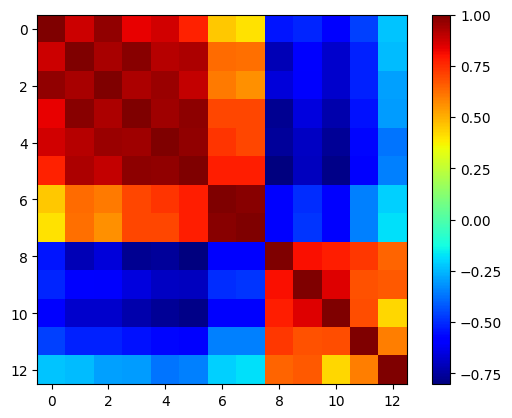

In [27]:
corr_coef_cube = np.corrcoef(np.hstack([bands_gpi, feats_gpi]).T)
plt.imshow(corr_coef_cube, cmap='jet')
plt.colorbar()
plt.show()

In [28]:
# features
A = np.vstack(
    [np.ones(feats_gpi.shape[0])] +
    [feats_gpi[:, i] for i in range(feats_gpi.shape[1])]
    ).T
A = np.clip(A, 0, None)
A.shape


(51764, 6)

In [29]:
B = []
for i in range(bands_gpi.shape[1]):
    B.append(np.linalg.lstsq(A, bands_gpi[:, i])[0])
    Y = np.dot(A, B[i])
    r = pearsonr(Y, bands_gpi[:, i])[0]
    print(i, r)

0 0.6496203792437252
1 0.8021322243491553
2 0.7340266471970214
3 0.8301839557426982
4 0.7920244328805273
5 0.8339671158853351
6 0.5923820417480252
7 0.6105440161224605


/tmp/ipykernel_2367325/3286347784.py:3: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  B.append(np.linalg.lstsq(A, bands_gpi[:, i])[0])


In [30]:

def cost(x, target, B):
    x_ = np.hstack([1, x])
    y = np.dot(x_[None], B)[0]
    return ((y - target)**2).mean()**0.5

def cost_x0(x, target, B, x0, x0w):
    x_ = np.hstack([1, x])
    y = np.dot(x_[None], B)[0]
    x_rmse = ((x - x0)**2).mean()**0.5
    y_rmse = ((y - target)**2).mean()**0.5
    return x0w * x_rmse + (1 - x0w) * y_rmse
#siconc, sithick, siconc_my, siage, si_ridge_ratio, sisnthick
bounds = [[0, 1], [0, 5], [0, 1], [0, 7], [0, 1], [0, 2]]
#sithick, siconc_my, siage, si_ridge_ratio, sisnthick
bounds = [[0, 5], [0, 1], [0, 7], [0, 1], [0, 2]]

bounds_gpi = np.array(bounds) * feats_scale[None].T + feats_offset[None].T

B_ = np.array(B).T
AA = np.array(A) + np.nan
E = np.zeros(A.shape[0])

def minimize_par(i):
    x0 = A[i, 1:]
    target = bands_gpi[i, :]
    m = minimize(cost_x0, x0, args=(target, B_, x0, 0.1), bounds=bounds_gpi)
    result = np.hstack([m.x, m.fun])
    return result

with Pool(10) as p:
    results = p.map(minimize_par, range(A.shape[0]))
results = np.array(results)

In [31]:
feats_new = np.zeros((bands.shape[0], bands.shape[1], feats_gpi.shape[1])) + np.nan
errrs = np.zeros_like(bands[:,:,0]) + np.nan
feats_new[gpi, :] = (results[:, :-1] - feats_offset) / feats_scale
errrs[gpi] = results[:, -1]


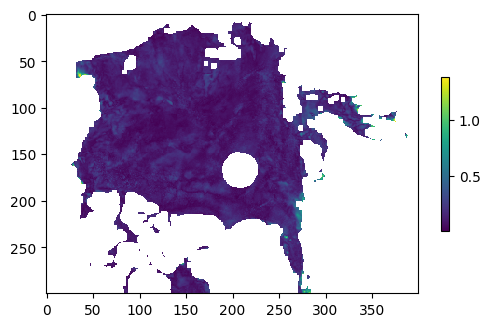

In [32]:
fig, axs = plt.subplots(1, 1, figsize=(6,4))
im = axs.imshow(errrs[300:600, 100:500], interpolation='nearest')
plt.colorbar(im, shrink=0.5)
plt.show()

sithick


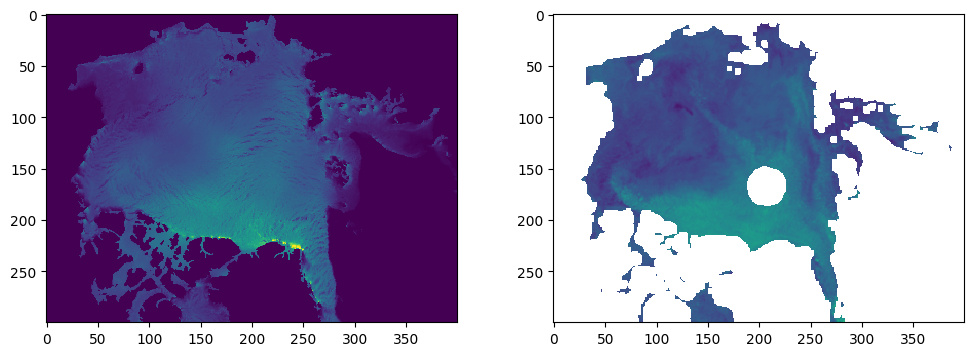

siconc_my


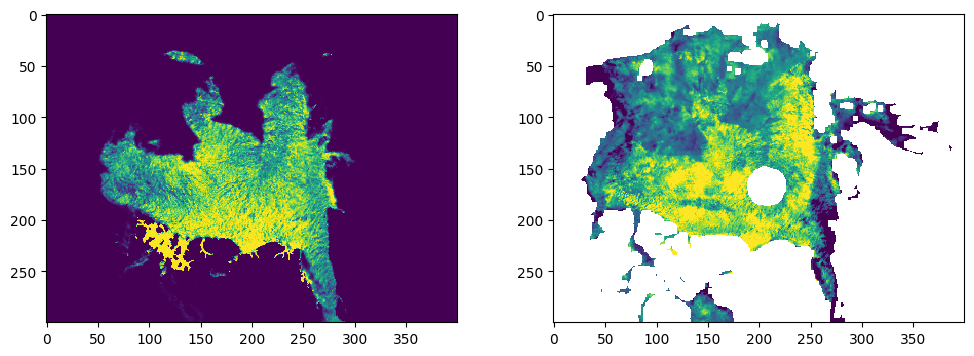

siage


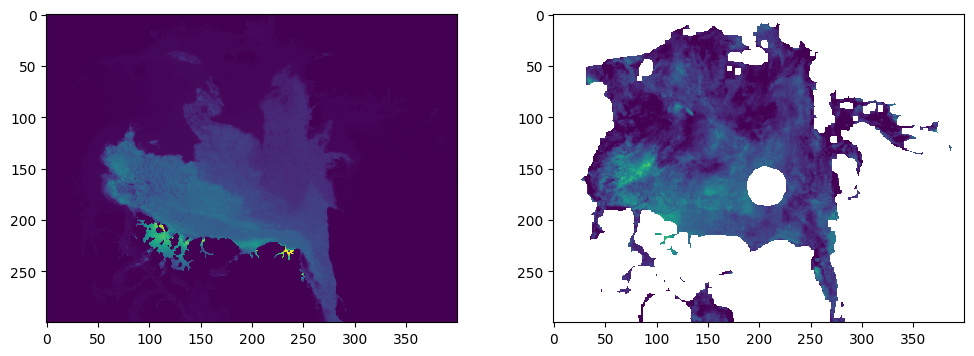

si_ridge_ratio


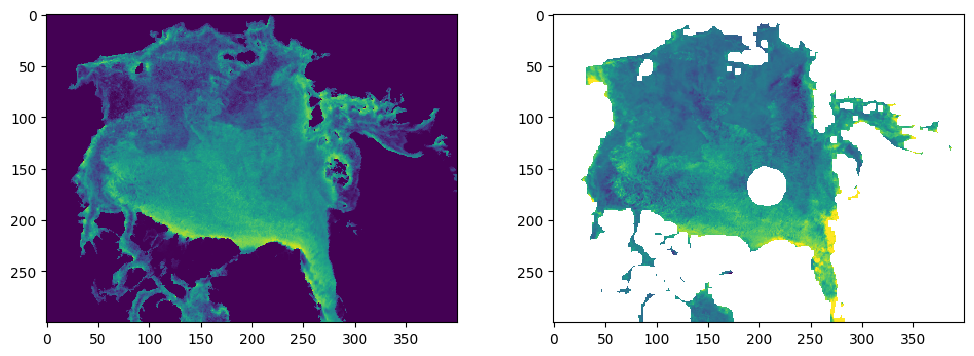

sisnthick


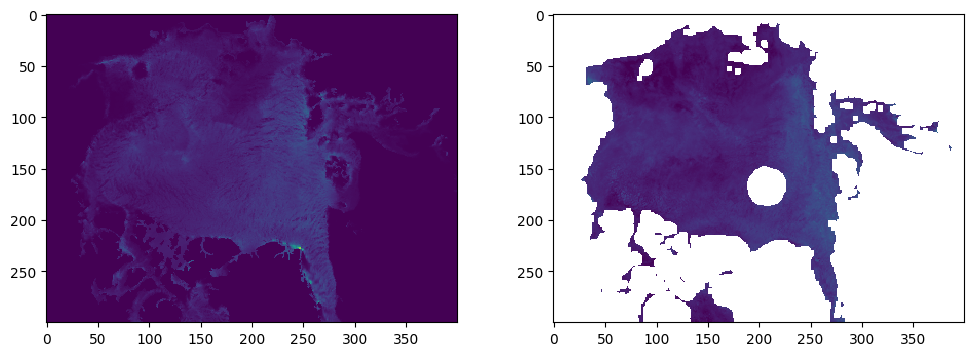

In [33]:
names = list(titles.keys())
for i in range(5):
    print(names[i])
    fig, axs = plt.subplots(1, 2, figsize=(12,4))
    axs[0].imshow(amsr_data[names[i]][300:600, 100:500], interpolation='nearest', clim=bounds[i])
    axs[1].imshow(feats_new[:,:,i][300:600, 100:500], interpolation='nearest', clim=bounds[i])
    plt.show()